In [7]:
import pandas as pd

# Load dataset
file_path = "../dataset.csv"  # Change path if needed
df = pd.read_csv(file_path)

# Convert 'datetime' to datetime object
df['datetime'] = pd.to_datetime(df['datetime'])

# Set 'datetime' as index and sort
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

# Fill missing values using forward fill
df = df.fillna(method='ffill')

# Feature Engineering: Add time-based features
df['hour'] = df.index.hour
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# Check result
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
 7   hour                   int32  
 8   day                    int32  
 9   day_of_week            int32  
 10  month                  int32  
dtypes: float64(7), int32(4)
memory usage: 158.3 MB
None
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00      

In [8]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Resample to hourly intervals using mean
df_resampled = df.resample('1H').mean()

# Normalize after resampling
scaler = MinMaxScaler()
df_resampled_scaled = pd.DataFrame(
    scaler.fit_transform(df_resampled),
    columns=df_resampled.columns,
    index=df_resampled.index
)

# Check result
print(df_resampled_scaled.info())
print(df_resampled_scaled.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: H
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34589 non-null  float64
 1   Global_reactive_power  34589 non-null  float64
 2   Voltage                34589 non-null  float64
 3   Global_intensity       34589 non-null  float64
 4   Sub_metering_1         34589 non-null  float64
 5   Sub_metering_2         34589 non-null  float64
 6   Sub_metering_3         34589 non-null  float64
 7   hour                   34589 non-null  float64
 8   day                    34589 non-null  float64
 9   day_of_week            34589 non-null  float64
 10  month                  34589 non-null  float64
dtypes: float64(11)
memory usage: 3.2 MB
None
                     Global_active_power  Global_reactive_power   Voltage  \
datetime                                         

In [9]:
import numpy as np

def create_masked_sequences(data, target_col='Global_active_power', window_size=24, mask_ratio=0.15):
    X, y, masks = [], [], []
    data_values = data.values.astype(np.float32)  # use float32 to reduce memory
    target_idx = data.columns.get_loc(target_col)

    for i in range(len(data) - window_size):
        seq = data_values[i:i+window_size]
        target = data_values[i+window_size, target_idx]

        # Create a mask for target feature
        mask = np.ones_like(seq)
        num_to_mask = int(mask_ratio * window_size)
        mask_indices = np.random.choice(window_size, num_to_mask, replace=False)
        mask[mask_indices, target_idx] = 0

        masked_seq = seq.copy()
        masked_seq[mask == 0] = 0

        X.append(masked_seq)
        y.append(target)
        masks.append(mask)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(masks, dtype=np.float32)


In [10]:
X, y, masks = create_masked_sequences(df_resampled_scaled, target_col='Global_active_power', window_size=24)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("masks shape:", masks.shape)


X shape: (34565, 24, 11)
y shape: (34565,)
masks shape: (34565, 24, 11)


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np


In [12]:
# 1. Robust Positional Encoding
def get_positional_encoding(seq_len, d_model):
    """
    Returns a [1, seq_len, d_model] positional encoding matrix
    for any integer d_model (even or odd).
    """
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]               # (seq_len, 1)
    div_term = np.exp(
        np.arange(0, int(np.ceil(d_model/2))) * 
        -(np.log(10000.0) / d_model)
    )                                                           # (ceil(d_model/2),)
    
    for i in range(d_model):
        j = i // 2
        if i % 2 == 0:
            pe[:, i] = np.sin(position[:, 0] * div_term[j])
        else:
            pe[:, i] = np.cos(position[:, 0] * div_term[j])
    
    return tf.constant(pe[np.newaxis, ...], dtype=tf.float32)  # (1, seq_len, d_model)


# 2. Transformer Model Builder
def build_transformer_model(seq_len, num_features, 
                            num_heads=4, ff_dim=128, dropout=0.1):
    inputs = layers.Input(shape=(seq_len, num_features))

    # Add positional encoding (matches num_features, even or odd)
    pos_encoding = get_positional_encoding(seq_len, num_features)
    x = inputs + pos_encoding

    # Single Transformer Encoder block
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=num_features
    )(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = layers.Dense(ff_dim, activation='relu')(x)
    ffn_output = layers.Dense(num_features)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    # Pool over time and predict one step ahead
    x = layers.GlobalAveragePooling1D()(x)
    output = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=inputs, outputs=output)
    return model


# 3. Instantiate & Compile
# model = build_transformer_model(seq_len=24, num_features=X.shape[2])
# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.summary()

model = build_transformer_model(
    seq_len=24, num_features=X.shape[2], num_heads=8, ff_dim=256, dropout=0.2
)

# Adjust optimizer with a learning rate scheduler
from tensorflow.keras.optimizers.schedules import ExponentialDecay

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4, decay_steps=100000, decay_rate=0.96, staircase=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])


# 4. Train
history = model.fit(
    X, y,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)



Epoch 1/10


433/433 [==============================] - 13s 22ms/step - loss: 0.0448 - mae: 0.1603 - val_loss: 0.0143 - val_mae: 0.1004
Epoch 2/10
433/433 [==============================] - 10s 22ms/step - loss: 0.0191 - mae: 0.1084 - val_loss: 0.0113 - val_mae: 0.0862
Epoch 3/10
433/433 [==============================] - 10s 22ms/step - loss: 0.0169 - mae: 0.1001 - val_loss: 0.0104 - val_mae: 0.0769
Epoch 4/10
433/433 [==============================] - 10s 22ms/step - loss: 0.0152 - mae: 0.0934 - val_loss: 0.0095 - val_mae: 0.0750
Epoch 5/10
433/433 [==============================] - 10s 22ms/step - loss: 0.0139 - mae: 0.0883 - val_loss: 0.0103 - val_mae: 0.0748
Epoch 6/10
433/433 [==============================] - 9s 22ms/step - loss: 0.0126 - mae: 0.0833 - val_loss: 0.0080 - val_mae: 0.0674
Epoch 7/10
433/433 [==============================] - 10s 23ms/step - loss: 0.0114 - mae: 0.0786 - val_loss: 0.0075 - val_mae: 0.0651
Epoch 8/10
433/433 [==============================] - 10s 23

Epoch 1/10
438/438 [==============================] - 8s 19ms/step - loss: 0.0097 - mae: 0.0713 - val_loss: 0.0071 - val_mae: 0.0627
Epoch 2/10
438/438 [==============================] - 9s 20ms/step - loss: 0.0095 - mae: 0.0705 - val_loss: 0.0068 - val_mae: 0.0624
Epoch 3/10
438/438 [==============================] - 10s 22ms/step - loss: 0.0093 - mae: 0.0694 - val_loss: 0.0069 - val_mae: 0.0616
Epoch 4/10
438/438 [==============================] - 9s 21ms/step - loss: 0.0092 - mae: 0.0691 - val_loss: 0.0068 - val_mae: 0.0611
Epoch 5/10
438/438 [==============================] - 9s 21ms/step - loss: 0.0092 - mae: 0.0689 - val_loss: 0.0069 - val_mae: 0.0614
Epoch 6/10
438/438 [==============================] - 9s 20ms/step - loss: 0.0090 - mae: 0.0684 - val_loss: 0.0068 - val_mae: 0.0616
Epoch 7/10
438/438 [==============================] - 10s 23ms/step - loss: 0.0090 - mae: 0.0683 - val_loss: 0.0069 - val_mae: 0.0614
Epoch 8/10
438/438 [==============================] - 10s 22ms/step

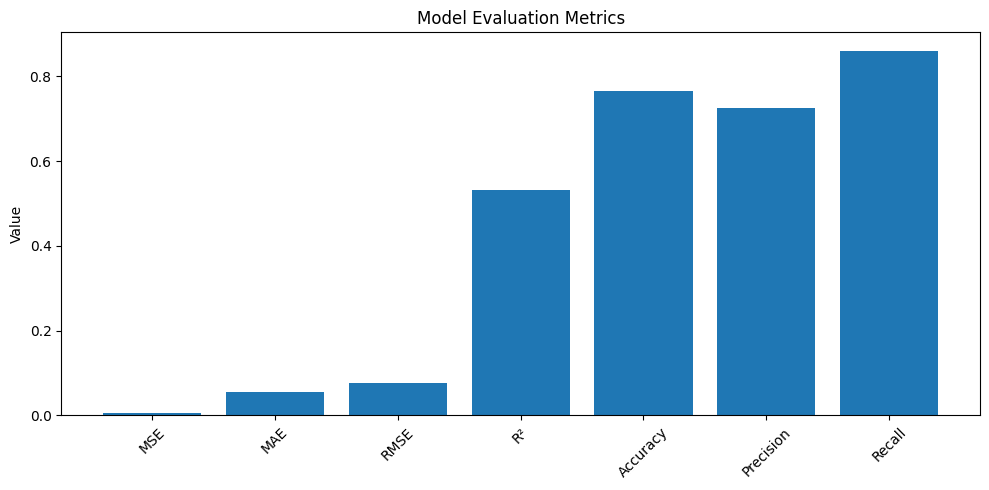

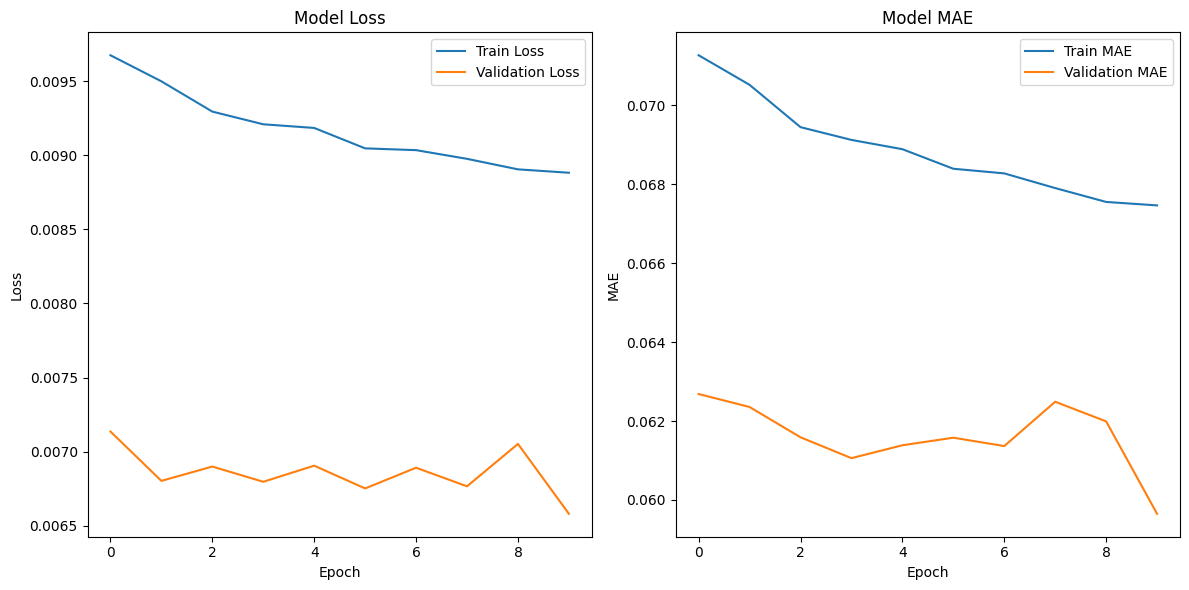

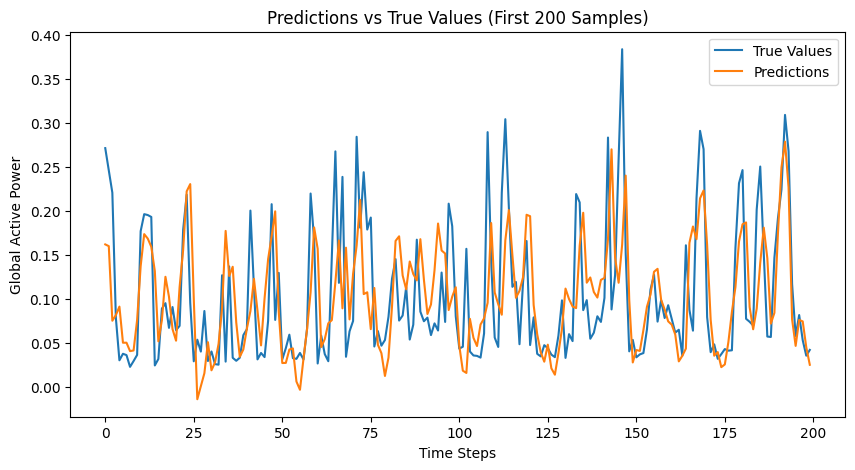

In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Create held-out test set (last 10% of data)
split_index = int(0.9 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# 2. (Re-)Train the model with a validation split
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# 3. Evaluate the model on the test set
test_results = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss (MSE):", test_results[0])
print("Test MAE:", test_results[1])

# 4. Generate predictions on the test set
y_pred = model.predict(X_test)

# 5. Compute regression metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse_val = mean_squared_error(y_test, y_pred)
mae_val = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 6. Define a threshold for classification metrics (median of true values)
threshold = np.median(y_test)
y_test_bin = (y_test > threshold).astype(int)
y_pred_bin = (y_pred.flatten() > threshold).astype(int)

# 7. Compute classification metrics (accuracy, precision, recall)
from sklearn.metrics import accuracy_score, precision_score, recall_score
acc = accuracy_score(y_test_bin, y_pred_bin)
prec = precision_score(y_test_bin, y_pred_bin, zero_division=0)
rec = recall_score(y_test_bin, y_pred_bin, zero_division=0)

# 8. Collect all metrics
metrics = {
    'MSE': mse_val,
    'MAE': mae_val,
    'RMSE': rmse,
    'R²': r2,
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec
}

# 9. Plot Metrics as a Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(metrics.keys(), metrics.values())
plt.title('Model Evaluation Metrics')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 10. Plot Training History (Loss & MAE)
plt.figure(figsize=(12, 6))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# MAE Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# 11. Plot Predictions vs Ground Truth (First 200 Samples)
plt.figure(figsize=(10, 5))
plt.plot(y_test[:200], label='True Values')
plt.plot(y_pred[:200], label='Predictions')
plt.title('Predictions vs True Values (First 200 Samples)')
plt.xlabel('Time Steps')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()


In [14]:
for name, value in metrics.items():
    # Format floats to 4 decimal places
    print(f"{name:10s}: {value:.4f}")

MSE       : 0.0058
MAE       : 0.0547
RMSE      : 0.0762
R²        : 0.5320
Accuracy  : 0.7668
Precision : 0.7244
Recall    : 0.8611


In [16]:
model.save('transformer_base.h5')


c:\Users\goyal\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
